<h1 style='text-align: center'>Recurrent Neural Network</h1>

<h2 style='text-align: center'>Imports</h2>

In [421]:
import numpy as np # Tensor library
import matplotlib.pyplot as plt # Graph rendering

<h2 style='text-align: center'>Create Data</h2>

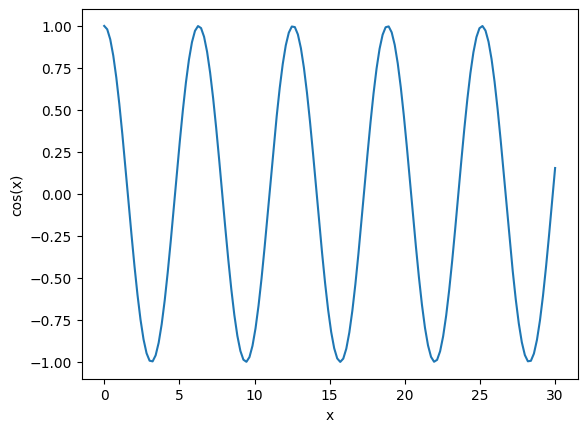

In [856]:
X = np.array([np.cos(x) for x in np.linspace(0, 30, 150)])
Y = np.array([np.cos(x) for x in np.linspace(1, 31, 150)])

plt.plot(np.linspace(0, 30, 150), X)
plt.xlabel("x")
plt.ylabel("cos(x)")
plt.show()

<h2 style='text-align: center'>Create Neural Network</h2>

<h3 style='text-align: center'>Tanh activation function and gradient</h3>

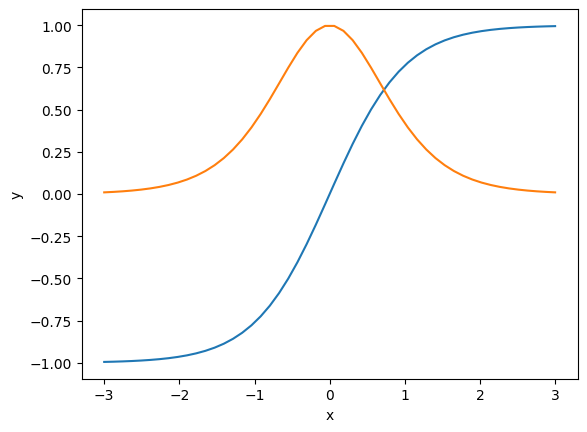

In [857]:
x = np.linspace(-3, 3)

def tanh(x):
    return np.tanh(x)

def tanh_grad(x):
    return 1 - np.tanh(x)**2

plt.plot(x, [tanh(i) for i in x])
plt.plot(x, [tanh_grad(i) for i in x])
plt.xlabel("x")
plt.ylabel("y")
plt.show()

<h3 style='text-align: center'>Mean Square Error loss function and gradient</h3>

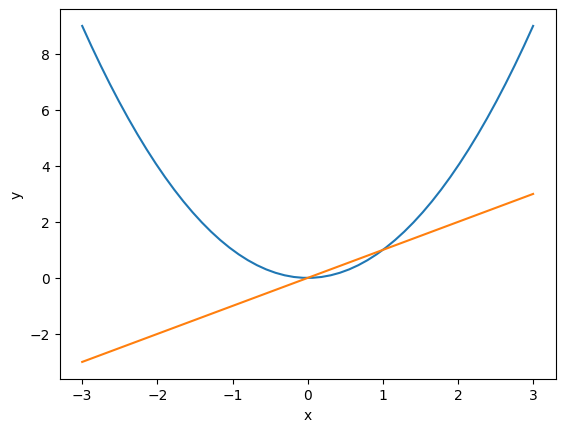

In [858]:
x = np.linspace(-3, 3)

def mse(predict, actual):
    return (predict - actual)**2

def mse_grad(predict, actual):
    return (predict - actual)

plt.plot(x, [mse(i, 0) for i in x])
plt.plot(x, [mse_grad(i, 0) for i in x])
plt.xlabel("x")
plt.ylabel("y")
plt.show()

<h3 style='text-align: center'>Feed Forward</h3>

Loss : 579.0424914327738


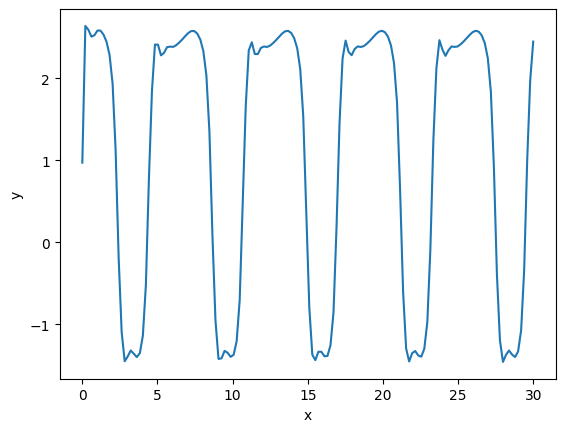

In [905]:
def forward(X):
    hiddens = []
    outputs = []
    prev_hidden = np.zeros((1, 5))
    for i in range(len(X)):
        x = X[i]
        hidden = tanh(np.dot(x, W_ih) + np.dot(prev_hidden, W_hh) + b_hh)
        hiddens.append(hidden)
        prev_hidden = hidden

        output = np.dot(hidden, W_ho) + b_ho
        outputs.append(output)
    l = len(outputs)
    return outputs, hiddens

# Feed forward parameters
W_ih = np.random.randn(1, 5)
W_hh = np.random.randn(5, 5)
W_ho = np.random.randn(5, 1)
b_hh = np.random.randn(1, 5)
b_ho = np.random.randn(1, 1)

outputs = []
hiddens = []
outputs, hiddens = forward(X)
print("Loss :", sum(mse(np.reshape(outputs, (150,)), Y)))

plt.plot(np.linspace(0, 30, 150), np.reshape(outputs, (150,)))
plt.xlabel("x")
plt.ylabel("y")
plt.show()

<h3 style='text-align: center'>Backpropagation</h3>

Loss before : 579.0424914327738
Loss after : 403.01577241350043


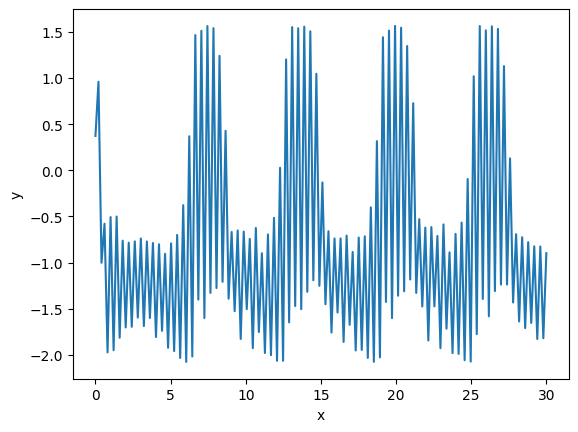

In [906]:
def backpropagate(X, Y, outputs, hiddens, learning_rate):
    global W_ho, b_ho, W_hh, W_ih, b_hh
    # Backpropagation parameters
    W_ih_grad = np.zeros((1, 5))
    W_hh_grad = np.zeros((5, 5))
    W_ho_grad = np.zeros((5, 1))
    b_hh_grad = np.zeros((1, 5))
    b_ho_grad = np.zeros((1, 1))

    losses_grad = mse_grad(np.reshape(outputs, (150,)), Y)
    next_hidden = None

    for i in range(len(outputs)-1, -1, -1):
        l_grad = losses_grad[i]
        h = hiddens[i]

        W_ho_grad += np.dot(h.T, l_grad)
        b_ho_grad += l_grad

        o_grad = np.dot(l_grad, W_ho.T)

        if i < len(outputs)-1:
            h_grad = o_grad + np.dot(next_hidden, W_hh.T)
        else:
            h_grad = o_grad
        
        tanh_derivative = 1 - h**2
        h_grad = np.multiply(h_grad, tanh_derivative)
        next_hidden = h_grad.copy()

        if i > 0:
            W_hh_grad += np.dot(hiddens[i-1].T, h_grad)
            b_hh_grad += h_grad
        
        W_ih_grad += np.dot(X[i].T, h_grad)


    W_ho -= W_ho_grad * learning_rate
    b_ho -= b_ho_grad * learning_rate
    W_hh -= W_hh_grad * learning_rate
    b_hh -= b_hh_grad * learning_rate
    W_ih -= W_ih_grad * learning_rate

# Feed forward parameters
W_ih = np.random.randn(1, 5)
W_hh = np.random.randn(5, 5)
W_ho = np.random.randn(5, 1)
b_hh = np.random.randn(1, 5)
b_ho = np.random.randn(1, 1)

learning_rate = 10e-2 / len(X)

print("Loss before :", sum(mse(np.reshape(outputs, (150,)),np.array(Y))))
backpropagate(X, Y, np.reshape(outputs, (150,)), hiddens, learning_rate)

outputs = []
hiddens = []
outputs, hiddens = forward(X)
print("Loss after :", sum(mse(np.reshape(outputs, (150,)),np.array(Y))))

plt.plot(np.linspace(0, 30, 150), np.reshape(outputs, (150,)))
plt.xlabel("x")
plt.ylabel("y")
plt.show()

<h2 style='text-align: center'>Training</h2>

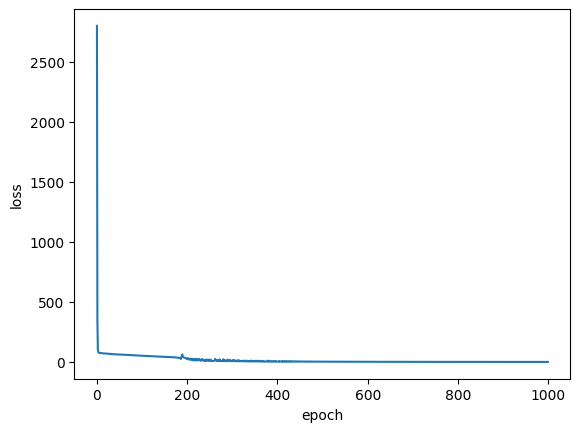

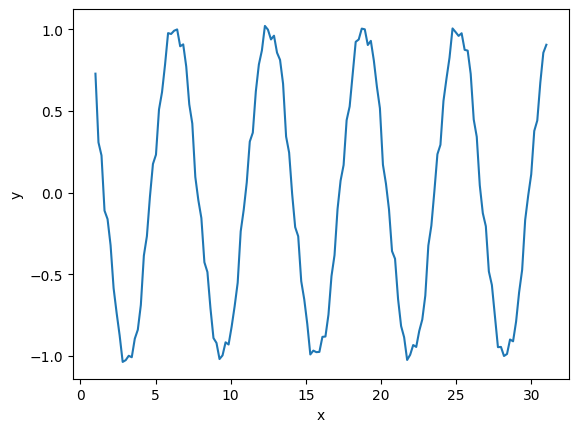

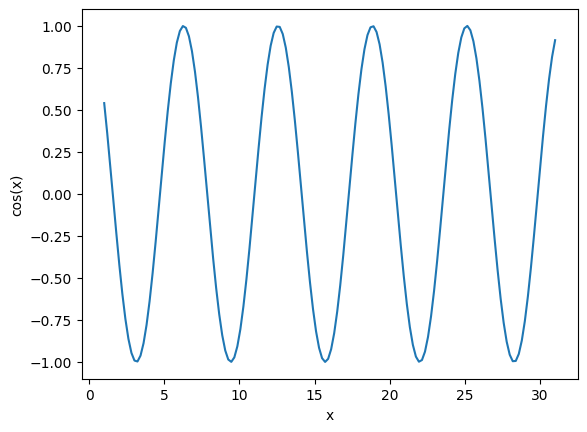

Total loss : 0.37509387817963546
Average loss : 0.0025006258545309033


In [941]:
learning_rate = 10e-2 / len(X)

# Feed forward parameters
W_ih = np.random.randn(1, 5)
W_hh = np.random.randn(5, 5)
W_ho = np.random.randn(5, 1)
b_hh = np.zeros((1, 5))
b_ho = np.zeros((1, 1))

losses = []
epochs = 1000
for i in range(epochs):
    outputs, hiddens = forward(X)
    backpropagate(X, Y, outputs, hiddens, learning_rate)
    loss = np.sum(mse(np.reshape(np.array(outputs), (150,)), Y))
    losses.append(loss)

plt.plot(range(epochs), losses)
plt.xlabel("epoch")
plt.ylabel("loss")
plt.show()

plt.plot(np.linspace(1, 31, 150), np.reshape(outputs, (150,)))
plt.xlabel("x")
plt.ylabel("y")
plt.show()

plt.plot(np.linspace(1, 31, 150), [np.cos(x) for x in np.linspace(1, 31, 150)])
plt.xlabel("x")
plt.ylabel("cos(x)")
plt.show()

print("Total loss :", np.sum(mse(np.reshape(np.array(outputs), (150,)), Y)))
print("Average loss :", np.mean(mse(np.reshape(np.array(outputs), (150,)), Y)))
